# 04 — Supervised Classification of MMS Plasma Regions with a CNN

**Purpose:** Train and evaluate a Convolutional Neural Network (CNN) that classifies MMS plasma regions directly from raw 2-D ion spectrograms, and interpret what the network has learned by visualising its convolutional feature maps.

> This notebook builds directly on notebooks 02 (preprocessing, PCA) and 03 (train/test split discipline). The key shift here is from **unsupervised** to **supervised** learning: we now use the region labels during training. The companion exercise notebook (04E) covers an MLP trained on PCA-compressed features.

## Learning Objectives

By the end of this notebook you will be able to:

- Explain the difference between supervised and unsupervised learning in the context of plasma region classification.
- Prepare a 2-D spectrogram dataset for use with a PyTorch CNN.
- Build and train a small CNN classifier on raw ion spectrograms.
- Interpret training curves to diagnose over- and under-fitting.
- Evaluate a classifier using accuracy, per-class F1 score, and a confusion matrix.
- Visualise convolutional feature maps and connect them to physical spectral patterns.

## Background

### From clustering to classification

In notebook 03 the clustering algorithms had no access to labels — they had to discover structure purely from data geometry. Here we flip to the **supervised** setting: each training sample carries a ground-truth region label, and the network learns to predict that label for unseen windows.

This is a more constrained problem — the loss function directly optimises what we care about — but it introduces a new responsibility: the training labels must be trustworthy. 

### Why a CNN?

The MLP in the companion exercise (04E) compresses the spectrogram down to 8 PCA components before classification. PCA is a linear transform and cannot represent non-linear spatial patterns — for example, a feature that appears only at a specific combination of energy channel *and* time step. A CNN learns such local patterns through its convolutional filters, and by stacking layers it can compose them into increasingly abstract feature detectors, without any manual feature engineering.

The input here is the raw 2-D spectrogram of shape `(N, n_bins)`, treated as a single-channel image. After `log10p1` preprocessing values sit in [0, ~8] and the spatial structure — the spectral shape over time — is intact.

### CNN architecture

We follow the reduced model of the CNN paper (this course's reading), using two small convolutional layers (1→4 and 4→4 feature maps with 3×3 kernels), a max-pool layer, and two fully connected layers. This architecture achieves ~94% accuracy on full-scale MMS data in the literature; our balanced small-dataset version reaches **99.0%** on the test set.

## 1 · Imports and Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset, DataLoader

from spacephyml.datasets.mms import SpectrumDataset
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report,
)
from pathlib import Path

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

figure_path = Path('./figures')
figure_path.mkdir(exist_ok=True)

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

NC_FILE = 'data/data_cleaned.nc'

REGION_NAMES  = {0: 'Solar Wind', 1: 'Ion Foreshock', 2: 'Magnetosheath', 3: 'Magnetosphere'}
REGION_LABELS = list(REGION_NAMES.values())
REGION_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
N_CLASSES     = 4
N_BINS        = 32

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cpu


## 2 · Preprocessing

We use the same `log10p1` scaling established in notebooks 02 and 03.

In [2]:
def preprocess(X: np.ndarray) -> np.ndarray:
    """
    Preprossing is done in two steps:
    1. Apply log₁₀(1 + x) scaling to a (samples, features) flux array.
    2. Add an axis for feature channel
    """
    return np.log10(1. + X)[np.newaxis,:,:]

## 3 · Load the Dataset

We use 5-minute windows (`N = 66` at 4.5 s cadence) with 521 balanced samples per class, giving 2,084 total samples across the four regions. Both a flattened version (for the companion MLP exercise) and a 2-D version (for the CNN here) are loaded from the same file so that comparisons are valid.

In [3]:
N       = 66     # ≈ 5 minutes at 4.5 s cadence
SAMPLES = 710    # windows per class (balanced)

# ── 2-D dataset (for CNN path) ────────────────────────────────────────────
ds_2d = SpectrumDataset(
    dataset_path=NC_FILE, trange=None, N=N, transform=preprocess,
    samples=SAMPLES, data_columns=None, flatten=False, verbose=True,
    fill_unknown=True, #Allow some "unknown" labels in windows if surronding labels are the same
)
X_raw_2d, y_raw_2d = ds_2d[:]
X_raw_2d = X_raw_2d.numpy()   # shape: (n_samples, N, n_bins)

print(f'2-D shape       : {X_raw_2d.shape}  (samples, time_steps, energy_bins)')
print(f'labels shape    : {y_raw_2d.shape}')

Max number of samples per classification is: 529
2-D shape       : (2116, 1, 66, 32)  (samples, time_steps, energy_bins)
labels shape    : torch.Size([2116])


## 4 · Train / Validation / Test Split

A 60/10/30 stratified split gives 1,269 training, 212 Validation and 635 test samples. The split is performed on raw indices before any preprocessing, consistent with notebooks 02 and 03.

In [4]:
VAL_SIZE = 0.10
TEST_SIZE = 0.30
_, y = ds_2d[:]
idx = np.arange(len(y))

# First split: train vs (test + val)
idx_train, idx_temp = train_test_split(
    idx, test_size=TEST_SIZE + VAL_SIZE, stratify=y, random_state=RANDOM_STATE,
)

# Second split: test vs val (from the temp pool)
y_temp = y[idx_temp]
relative_val_size = VAL_SIZE / (TEST_SIZE + VAL_SIZE)  # ~0.5 if both are 0.15
idx_test, idx_val = train_test_split(
    idx_temp, test_size=relative_val_size, stratify=y_temp, random_state=RANDOM_STATE,
)

ds_train = Subset(ds_2d, idx_train)
ds_val   = Subset(ds_2d, idx_val)
ds_test  = Subset(ds_2d, idx_test)

BATCH_SIZE = 32
train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(ds_train)}  Val: {len(ds_val)} Test: {len(ds_test)}")

Train: 1269  Val: 212 Test: 635


## 5 · CNN Architecture

Two convolutional layers extract local time–energy features. The first layer (1→4 maps) detects low-level patterns; the second (4→4 maps) combines them. Max-pooling halves the spatial dimensions and provides translation invariance. Two fully connected layers then map the flattened feature volume to four class logits.

The flat size after the convolutional stack is computed automatically using a dummy forward pass — so the code is robust to any `(N, n_bins)` input shape.

In [5]:
class CNN(nn.Module):
    """Small CNN for 2-D ion spectrogram classification.

    Input:  (batch, 1, N, n_bins)  — single-channel spectrogram
    Output: (batch, n_classes)     — raw logits
    """
    def __init__(self, n_time: int, n_bins: int,
                 n_classes: int = 4, dropout: float = 0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 4, kernel_size=3, padding=0),   # 1 → 4 feature maps
            nn.ReLU(),
            nn.Conv2d(4, 4, kernel_size=3, padding=0),   # 4 → 4 feature maps
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                  # halve spatial dims
        )
        # Compute flattened size after conv+pool automatically
        dummy     = torch.zeros(1, 1, n_time, n_bins)
        flat_size = self.features(dummy).numel()

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, 128),
            nn.ReLU(),
            nn.Linear(128, n_classes),
            nn.Softmax(dim=-1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


cnn = CNN(n_time=N, n_bins=N_BINS, n_classes=N_CLASSES).to(DEVICE)
print(cnn)
n_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params:,}")

CNN(
  (features): Sequential(
    (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(4, 4, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1736, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=4, bias=True)
    (4): Softmax(dim=-1)
  )
)

Trainable parameters: 223,040


## 6 · Training Loop

Cross-entropy loss is the standard for multi-class classification — it penalises confident wrong predictions much more than uncertain ones. The Adam optimiser with a `ReduceLROnPlateau` scheduler halves the learning rate when test loss plateaus, and early stopping restores the best checkpoint to avoid over-fitting.

The CNN converges quickly: training stops after just 34 epochs, reaching 99.0% test accuracy.

In [6]:
def train_model(model, train_loader, val_loader,
                n_epochs=100, lr=1e-3, patience=15):
    """Train a model and record loss/accuracy curves.
    Returns history dict with keys 'train_loss', 'validation_loss',
    'train_acc', 'val_acc'.
    """
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimiser = optim.Adam(model.parameters(), lr=lr)
    
    history = {k: [] for k in ('train_loss', 'val_loss', 'train_acc', 'val_acc')}
    best_loss, best_weights, wait = np.inf, None, 0

    for epoch in range(1, n_epochs + 1):
        # ── Training pass ──────────────────────────────────────────────
        model.train()
        run_loss, correct, total = 0., 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimiser.zero_grad()
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            loss.backward()
            optimiser.step()
            run_loss += loss.item() * len(y_batch)
            correct  += (logits.argmax(1) == y_batch).sum().item()
            total    += len(y_batch)
        history['train_loss'].append(run_loss / total)
        history['train_acc'].append(correct / total)

        # ── Evaluation pass ────────────────────────────────────────────
        model.eval()
        run_loss, correct, total = 0., 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                logits = model(X_batch)
                loss   = criterion(logits, y_batch)
                run_loss += loss.item() * len(y_batch)
                correct  += (logits.argmax(1) == y_batch).sum().item()
                total    += len(y_batch)
        val_loss = run_loss / total
        history['val_loss'].append(val_loss)
        history['val_acc'].append(correct / total)

        # ── Early stopping ─────────────────────────────────────────────
        if val_loss < best_loss:
            best_loss    = val_loss
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stop at epoch {epoch}")
                break

        if epoch % 20 == 0 or epoch == 1:
            print(f"  Epoch {epoch:>4d}  "
                  f"train loss={history['train_loss'][-1]:.4f}  acc={history['train_acc'][-1]:.3f}  |  "
                  f"val  loss={history['val_loss'][-1]:.4f}  acc={history['val_acc'][-1]:.3f}")

    model.load_state_dict(best_weights)   # restore best checkpoint
    return history

In [7]:
print("Training CNN...")
history_cnn = train_model(cnn, train_loader, val_loader,
                           n_epochs=300, lr=1e-3, patience=20)

Training CNN...
  Epoch    1  train loss=1.1941  acc=0.587  |  val  loss=0.9638  acc=0.873
  Epoch   20  train loss=0.7585  acc=0.987  |  val  loss=0.7688  acc=0.986
  Epoch   40  train loss=0.7511  acc=0.993  |  val  loss=0.7528  acc=0.991
  Epoch   60  train loss=0.7484  acc=0.995  |  val  loss=0.7477  acc=0.995
  Early stop at epoch 72


## 7 · Training Curves

The CNN loss drops steeply in the first few epochs and the train/test curves track closely throughout — the model is not over-fitting. The test accuracy reaches >99% by epoch 20 and remains there, which is why early stopping triggers at epoch 34.

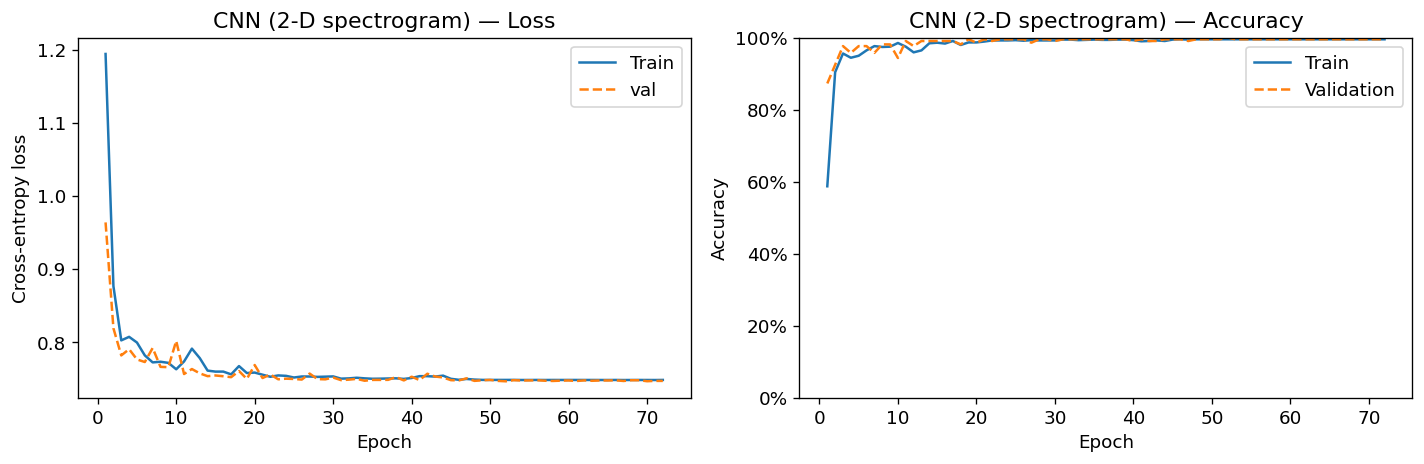

In [8]:
def plot_history(history: dict, title: str):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], label='Train')
    axes[0].plot(epochs, history['val_loss'],  label='val', linestyle='--')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-entropy loss')
    axes[0].set_title(f'{title} — Loss'); axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], label='Train')
    axes[1].plot(epochs, history['val_acc'],  label='Validation', linestyle='--')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1); axes[1].set_title(f'{title} — Accuracy')
    axes[1].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(figure_path / '04_cnn_trainign_val_loss.png', bbox_inches='tight')

plot_history(history_cnn, 'CNN (2-D spectrogram)')

## 8 · Evaluate the CNN

On the 626-sample test set the CNN achieves **99.0% accuracy** with macro-averaged F1 of 0.99. All four regions are classified near-perfectly; Solar Wind and Ion Foreshock have marginally lower F1 (0.98) — the same pair that caused the most difficulty in the unsupervised clustering of notebook 03, for the same physical reason: both have narrow, high-energy spectral peaks.

In [9]:
def evaluate(model, loader) -> np.ndarray:
    """Return predicted class labels for all samples in loader."""
    model.eval()
    preds = []
    with torch.no_grad():
        for X_batch, _ in loader:
            preds.append(model(X_batch.to(DEVICE)).argmax(1).cpu().numpy())
    return np.concatenate(preds)

y_pred = evaluate(cnn, test_loader)
_, y_test = ds_test[:]
print("CNN — test set results")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}\n")
print(classification_report(y_test, y_pred, target_names=REGION_LABELS))

CNN — test set results
Accuracy: 0.994

               precision    recall  f1-score   support

   Solar Wind       0.99      1.00      1.00       159
Ion Foreshock       1.00      0.97      0.99       158
Magnetosheath       0.98      1.00      0.99       159
Magnetosphere       1.00      1.00      1.00       159

     accuracy                           0.99       635
    macro avg       0.99      0.99      0.99       635
 weighted avg       0.99      0.99      0.99       635



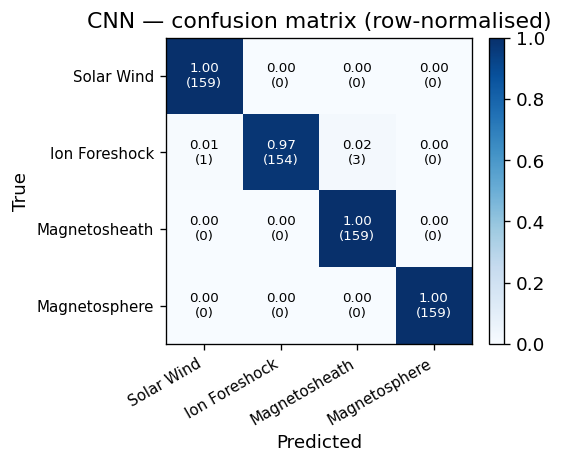

In [10]:
def plot_confusion(y_true, y_pred, title):
    cm      = confusion_matrix(y_true, y_pred, labels=list(range(N_CLASSES)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm_norm, vmin=0, vmax=1, cmap='Blues')
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            color = 'white' if cm_norm[i, j] > 0.6 else 'black'
            ax.text(j, i, f"{cm_norm[i,j]:.2f}\n({cm[i,j]})",
                    ha='center', va='center', fontsize=8, color=color)
    ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels(REGION_LABELS, rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(REGION_LABELS, fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(figure_path / '04_cnn_confusion.png', bbox_inches='tight')

plot_confusion(y_test, y_pred, 'CNN — confusion matrix (row-normalised)')

## 9 · What Does the CNN See? Feature Maps

Attaching a forward hook to the first convolutional layer lets us inspect what each of the four filters activates on. A filter that lights up strongly at high-energy bins for Solar Wind but stays dark for Magnetosphere is acting as a learned high-energy detector — directly analogous to the PC vectors visualised in notebook 02, but discovered from the labels rather than from variance.

The diverging colourmap (red = positive activation, blue = negative) shows which time–energy regions push the input toward or away from each filter's learned pattern.

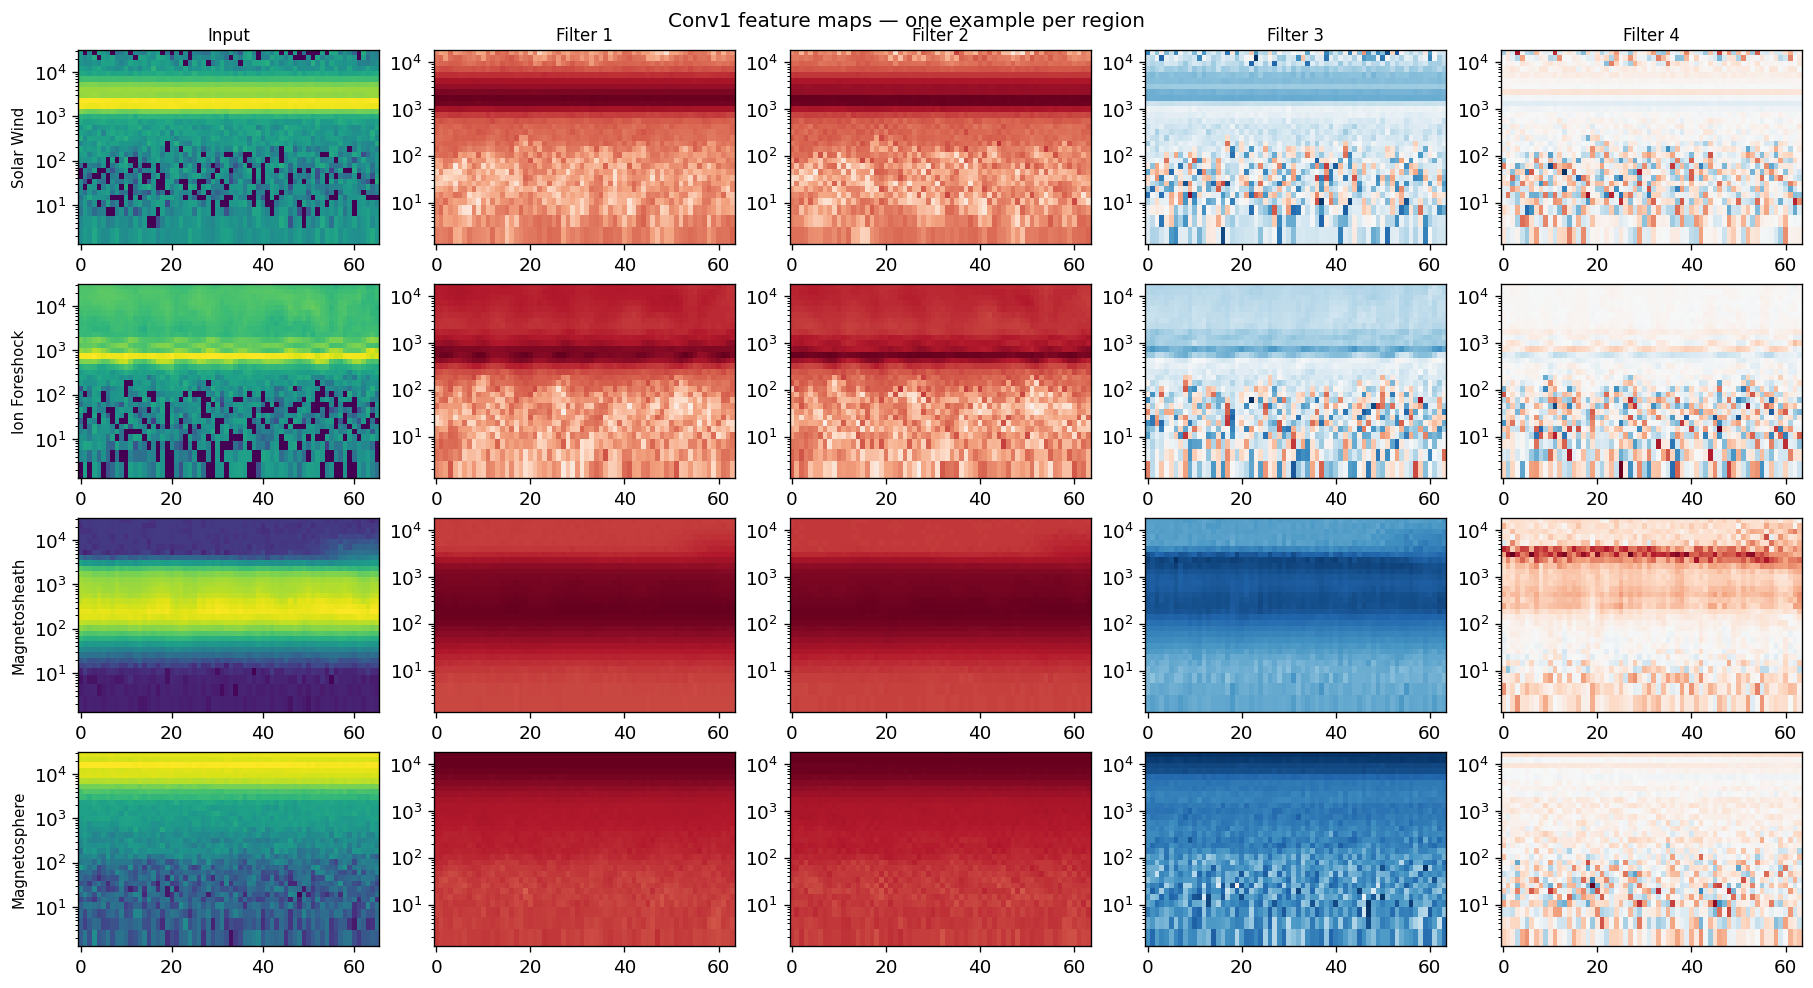

In [11]:
N_FILTERS_SHOW = 4   # Conv1 has 4 filters; show all of them

cnn.eval()
hook_output = {}

def hook_fn(module, inp, out):
    hook_output['conv1'] = out.detach().cpu()

handle = cnn.features[0].register_forward_hook(hook_fn)

fig, axes = plt.subplots(
    N_CLASSES, 1 + N_FILTERS_SHOW,
    figsize=(3 * (1 + N_FILTERS_SHOW), 2 * N_CLASSES),
    layout='constrained',
)

spec_lev = ds_2d.bin_centers[0, 0]   # energy axis

for row, (label, name) in enumerate(REGION_NAMES.items()):
    idx_region = np.where(y_test == label)[0][0]
    x_sample   = ds_test[idx_region:idx_region+1][0]

    with torch.no_grad():
        _ = cnn(x_sample.to(DEVICE))

    maps = hook_output['conv1'][0]   # (4, N', n_bins')

    # Input spectrogram
    ax = axes[row, 0]
    ax.pcolormesh(np.arange(N), spec_lev,
                  x_sample.detach().numpy().squeeze().T,
                  cmap='viridis', shading='auto')
    ax.set_yscale('log')
    if row == 0: ax.set_title('Input', fontsize=10)
    ax.set_ylabel(name, fontsize=9)

    # Feature maps
    for col in range(N_FILTERS_SHOW):
        ax   = axes[row, col + 1]
        fmap = maps[col].numpy()
        vmax = np.abs(fmap).max()
        ax.pcolormesh(np.arange(fmap.shape[0]), spec_lev[:fmap.shape[1]],
                      fmap.T, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                      shading='auto')
        ax.set_yscale('log')
        if row == 0: ax.set_title(f'Filter {col+1}', fontsize=10)

handle.remove()
plt.suptitle("Conv1 feature maps — one example per region", y=1.01, fontsize=12)
plt.savefig(figure_path / '04_cnn_conv_feature_maps.png', bbox_inches='tight')

## Summary

**What we did:**

- Loaded 2,084 balanced 5-minute MMS windows, applied `log10p1` preprocessing, and split 70/30 — 1,458 training, 626 test samples.
- Built a small CNN (`Conv2d(1→4) → Conv2d(4→4) → MaxPool → FC(1736→128) → FC(128→4)`, 223,040 parameters) operating on `(66, 32)` spectrograms.
- Trained with Adam and early stopping; the model converged in 34 epochs.
- Achieved **99.0% test accuracy** with near-perfect F1 across all four regions.

**Key takeaways:**

1. **Supervised learning dramatically outperforms unsupervised clustering.** The CNN's 99.0% accuracy compares to ~ARI ≈ 0.7–0.8 for the best clustering in notebook 03 — directly optimising against labels makes a large difference when reliable labels are available.
3. **Solar Wind and Ion Foreshock remain the hardest pair.** F1 = 0.98 for both; both have narrow high-energy peaks. This is a data-level limitation, not a model failure — richer features (e.g. magnetic field, pitch-angle distributions) would be needed to push further.
4. **Feature maps are physically interpretable.** The four Conv1 filters learn distinct energy-localised patterns — directly analogous to the PCA eigenvector spectrograms in notebook 02, but optimised for discrimination rather than variance.
5. **Training curves are the first diagnostic.** A close train/test gap here indicates healthy generalisation; dropout and early stopping were sufficient regularisation for this dataset size.

**Further reading:**

- Olshevsky et al. (2021) — original CNN for MMS plasma region classification
- Argall et al. (2020) — CNN trained on SITL-labelled MMS data
- LeCun et al. (1998) — foundational CNN paper
- PyTorch: [torch.nn docs](https://pytorch.org/docs/stable/nn.html), [CIFAR-10 tutorial](https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html)